In [1]:
from os import chdir
from pathlib import Path

cwd = Path.cwd()
print(f"CWD: {cwd}")
if cwd.name == "code":
    chdir("..")
print(f"CWD: {Path.cwd()}")

CWD: /home/james/git/research/fed-learning/code
CWD: /home/james/git/research/fed-learning


In [2]:
from src.models.MatrixFactorization import MF, UMF
from src.graphs import random_k_out_graph
from src.users import User
from src.training.decentralized import decentralized_train_loop, decentralized_validate_loop
from src.data_utils import create_batched_dataloaders, create_dataloader

In [3]:
#Make data sample iterable
from torch.utils.data import Dataset, DataLoader, TensorDataset, Sampler
import torch
from tqdm.notebook import tqdm

import pandas as pd
import numpy as np

import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.optim.lr_scheduler import ReduceLROnPlateau
from torch.optim import SGD

from collections import Counter
import networkx as nx
from networkx.generators.classic import empty_graph
from networkx.utils import discrete_sequence, py_random_state, weighted_choice

import seaborn as sns

In [4]:
# train_df = pd.read_csv("dataset/ml100k_train.csv")
# val_df = pd.read_csv("dataset/ml100k_test.csv")
# n_users = train_df['customer_id'].nunique()
# n_items = train_df['product_code'].nunique()
# train_df.head()

In [5]:
train_df = pd.read_csv("dataset/hm_train_df.csv")
val_df = pd.read_csv("dataset/hm_val_df.csv")
n_users = train_df['customer_id'].nunique()
n_items = train_df['product_code'].nunique()
train_df

,customer_id,product_code,bought
0,0,0,2
1,0,1,2
2,0,2,1
3,0,3,1
4,0,4,1
...,...,...,...
86475,1759,408,1
86476,1759,1052,2
86477,1759,1411,1
86478,1759,906,1


In [6]:
X_train = train_df[["customer_id", "product_code"]]
X_train.columns = ["user_id", "item_id"]
y_train = train_df["bought"]

X_test = val_df[["customer_id", "product_code"]]
X_test.columns = ["user_id", "item_id"]
y_test = val_df["bought"]
# y_train.columns = [""]

In [7]:
class UserStratifiedDataset(Dataset):
    def __init__(self, x: np.ndarray, y: np.ndarray):
        self.x = torch.tensor(x)
        self.y = torch.tensor(y)

    def __len__(self):
        return len(self.x[:, 0].unique())

    def __getitem__(self, user):
        user_idx = self.x[:, 0] == user
        return self.x[user_idx, :], self.y[user_idx]
        

In [8]:
#Random_5_out Graph
graph = random_k_out_graph(n_users,5,50)

In [9]:
def validate(models, val_loader, schedulers):

    tbar = val_loader
    loss_fn = nn.MSELoss(reduction="sum")
    loss_list = []
    for i in range(len(models)):
        models["model{0}".format(i)].eval()

    total_obs = 0
    total_sum_loss = 0
    with torch.no_grad():
        for idx, (inputs, target) in enumerate(tbar):
            # print(f"before: {inputs.shape=}")
            # print(f"before: {target.shape=}")
            if inputs.ndim == 3:
                inputs = inputs.squeeze(0)
                target = target.squeeze(0)
            # print(f"after: {inputs.shape=}")
            # print(f"after: {target.shape=}")
            n_obs = len(target)
            
            if target.shape[0] == 0:
                continue
            # if len(target) == 1:
                # print(f"{inputs=}")
                # print(f"{target=}")
            user_id = int(inputs[0, 0])
            score = models["model{0}".format(user_id)](inputs[:,0], inputs[:, 1])

            sum_loss = loss_fn(score, target.float()).detach().numpy()
            mean_loss = sum_loss / n_obs
            
            total_sum_loss += sum_loss
            total_obs += n_obs
            
            sched = schedulers[f"model{user_id}"]
            if sched is not None:
                sched.step(mean_loss)

        total_loss = np.sqrt(total_sum_loss / total_obs)
    return total_loss

def validate_one_at_a_time(models, val_loader, schedulers):

    tbar = val_loader
    loss_fn = nn.MSELoss()
    loss_list = []
    for i in range(len(models)):
        models["model{0}".format(i)].eval()

    with torch.no_grad():
        for idx, (inputs, target) in enumerate(tbar):
            user_id = int(inputs[0, 0])
            logits = models["model{0}".format(int(inputs[:, 0]))](inputs[:,0], inputs[:,1])
            loss = loss_fn(score, target.float())
            sched = schedulers[f"model{user_id}"]
            if sched is not None:
                sched.step(loss)

            loss_list.append(loss.detach().cpu().item())
        avg_loss = np.sqrt(np.mean(loss_list))

    return avg_loss

# val_dataset = HMDataset(X_test,y_test)
# val_loader = DataLoader(val_dataset, batch_size=1, shuffle=False)

# val_dataset = HMDataset(X_test,y_test)
# val_loader = DataLoader(val_dataset, batch_size=1, shuffle=False)

In [10]:
def init_models(n_users, n_items, sparse=False):
    #Models Initialization
    models = {}
    for x in tqdm(range(n_users)):
        models["model{0}".format(x)] = MF(n_users,n_items, sparse=sparse)
    return models

#Optimizer selection
def get_optimizer(model, sparse=False, lr=0.01, n_obs=1):
    if sparse:
        return torch.optim.SparseAdam(model.parameters(), lr=lr)
    else:
        return torch.optim.SGD(model.parameters(), lr=lr)

def get_scheduler(optimizer, kind=None):
    if kind is not None:
        return ReduceLROnPlateau(optimizer, patience=3)
    else:
        return None

In [11]:
def train(models, train_loader, epochs, val_loader, sparse=False):
    #Initialize Optimizers
    optimizers = {}
    schedulers = {}
    for i in tqdm(range(n_users)):
        optimizer = get_optimizer(models["model{0}".format(i)], sparse=sparse)
        optimizers["model{0}".format(i)] = optimizer
        schedulers["model{0}".format(i)] = get_scheduler(optimizer, kind=None)
        
    loss_fn = nn.MSELoss(reduction="mean")
    val_losses = []
    val_loss = validate(models, val_loader, schedulers)
    val_losses.append(val_loss)

    for e in range(epochs):
        tbar = tqdm(train_loader)
        for i in range(len(models)):
            models["model{0}".format(i)].train()
        # loss_list = []
        losses = np.empty(len(train_loader))
        total_n_obs = 0
        total_sum_loss = 0
        for idx, (inputs, target) in enumerate(tbar):
            # inputs, target = read_data(data)
            # # inputs = inputs[0]
            if inputs.ndim == 3:
                inputs = inputs.squeeze(0)
                target = target.squeeze(0)
            n_obs = target.shape[0]
            # print(f"{inputs.shape=}")
            # print(f"{target.shape=}")
            user_id = int(inputs[0, 0])
            optimizer = optimizers["model{0}".format(user_id)]
            optimizer.zero_grad()
            logits = models["model{0}".format(user_id)](inputs[:,0], inputs[:, 1])
            # loss = loss_fn(logits, target.float()) / n_obs
            loss = loss_fn(logits, target.float())
            loss.backward()#Calculate Gradients

            #Get gradients of current Model
            model_gradient = {}#Store current gradients
            for name,param in models["model{0}".format(int(inputs[0, 0]))].named_parameters():
                gradient = param.grad
                model_gradient[name] = gradient

            #Assign gradients to neighbors' Model
            user_n = Graph.adj[user_id]
            # user_n = list(Adjacency_List[int(inputs[0])])
            #user_n = []  #uncomment it for local learning
            for neighbor in user_n:
                neighbor_model = models["model{0}".format(neighbor)]
                neighbor_optimizer = optimizers["model{0}".format(neighbor)]
                neighbor_model.zero_grad()
                for name,param in neighbor_model.named_parameters():
                    param.grad = model_gradient[name] #Assign gradients to the neighbors
                neighbor_optimizer.step()#Neighbors' update

            optimizer.step()#Current user's update

            total_n_obs += n_obs
            total_sum_loss += loss.detach().numpy()
            losses[idx] = loss.detach().numpy()
            # loss_list.append(loss.detach().cpu().item())
            avg_loss = losses[:idx+1].mean()
            # avg_loss = total_sum_loss / total_n_obs
            if idx % 1000 == 0:
                tbar.set_description(f"Epoch {e+1} Loss: {np.sqrt(avg_loss):.05f} ")

        val_loss = validate(models, val_loader, schedulers)
        
        
        val_losses.append(val_loss)
        log_text = f"Epoch {e+1}\nTrain Loss: {np.sqrt(avg_loss)}\nValidation Loss: {val_loss}\n"
        print(log_text)
    return val_losses

## Train User-Stratified

In [16]:
models = init_models(n_users, n_items, sparse=False)
user_dataset = UserStratifiedDataset(X_train.to_numpy(), y_train.to_numpy())
user_dataloader = DataLoader(user_dataset, batch_size=1, shuffle=True)

val_dataset = TensorDataset(torch.tensor(X_test.to_numpy(), dtype=int), torch.tensor(y_test.to_numpy(), dtype=float))
val_loader = DataLoader(val_dataset, batch_size=1, shuffle=True)

  0%|          | 0/1760 [00:00<?, ?it/s]

In [17]:
val_loss = train(models, user_dataloader, epochs=1, val_loader=val_loader)

  0%|          | 0/1760 [00:00<?, ?it/s]

/home/james/git/research/fed-learning/.venv/lib/python3.10/site-packages/torch/nn/modules/loss.py:535: UserWarning: Using a target size (torch.Size([1])) that is different to the input size (torch.Size([1, 1])). This will likely lead to incorrect results due to broadcasting. Please ensure they have the same size.
  return F.mse_loss(input, target, reduction=self.reduction)


  0%|          | 0/1760 [00:00<?, ?it/s]

/home/james/git/research/fed-learning/.venv/lib/python3.10/site-packages/torch/nn/modules/loss.py:535: UserWarning: Using a target size (torch.Size([61])) that is different to the input size (torch.Size([61, 1])). This will likely lead to incorrect results due to broadcasting. Please ensure they have the same size.
  return F.mse_loss(input, target, reduction=self.reduction)
/home/james/git/research/fed-learning/.venv/lib/python3.10/site-packages/torch/nn/modules/loss.py:535: UserWarning: Using a target size (torch.Size([50])) that is different to the input size (torch.Size([50, 1])). This will likely lead to incorrect results due to broadcasting. Please ensure they have the same size.
  return F.mse_loss(input, target, reduction=self.reduction)
/home/james/git/research/fed-learning/.venv/lib/python3.10/site-packages/torch/nn/modules/loss.py:535: UserWarning: Using a target size (torch.Size([40])) that is different to the input size (torch.Size([40, 1])). This will likely lead to incor

Epoch 1
Train Loss: 5.916302522845599
Validation Loss: 5.82978170116542



In [2]:
val_loss #Evaluation

NameError: name 'val_loss' is not defined

## User-Stratified with Val

In [29]:
models2 = init_models(n_users, n_items, sparse=False)
user_val_dataset = UserStratifiedDataset(X_test.to_numpy(), y_test.to_numpy())
user_val_dataloader = DataLoader(user_val_dataset, batch_size=1, shuffle=True)
val_loss = train(models2, user_dataloader, epochs=70, val_loader=user_val_dataloader)

  0%|          | 0/1760 [00:00<?, ?it/s]

  0%|          | 0/1760 [00:00<?, ?it/s]

  0%|          | 0/1760 [00:00<?, ?it/s]

Epoch 1
Train Loss: 5.8899638894563955
Validation Loss: 27.83449950738222



  0%|          | 0/1760 [00:00<?, ?it/s]

Epoch 2
Train Loss: 5.584883290141747
Validation Loss: 27.293641662800926



  0%|          | 0/1760 [00:00<?, ?it/s]

Epoch 3
Train Loss: 5.316790720772457
Validation Loss: 26.798187899163274



  0%|          | 0/1760 [00:00<?, ?it/s]

KeyboardInterrupt: 

## Train OAAT Val OAAT

In [ ]:
models3 = init_models(n_users, n_items, sparse=False)

In [13]:
train_dataset = TensorDataset(torch.tensor(X_train.to_numpy(), dtype=int), torch.tensor(y_train.to_numpy(), dtype=float))
train_loader = DataLoader(train_dataset, batch_size=1, shuffle=True)

val_dataset = TensorDataset(torch.tensor(X_test.to_numpy(), dtype=int), torch.tensor(y_test.to_numpy(), dtype=float))
val_loader = DataLoader(val_dataset, batch_size=1, shuffle=True)

In [18]:
val_loss3 = train(models3, train_loader, epochs=1, val_loader=val_loader)

  0%|          | 0/1760 [00:00<?, ?it/s]

/home/james/git/research/fed-learning/.venv/lib/python3.10/site-packages/torch/nn/modules/loss.py:535: UserWarning: Using a target size (torch.Size([1])) that is different to the input size (torch.Size([1, 1])). This will likely lead to incorrect results due to broadcasting. Please ensure they have the same size.
  return F.mse_loss(input, target, reduction=self.reduction)


  0%|          | 0/86480 [00:00<?, ?it/s]

Epoch 1
Train Loss: 4.4178179106582025
Validation Loss: 3.4377307870730736



In [12]:
users3 = {}
for i in tqdm(range(n_users)):
    model = MF(n_users=n_users, n_items=n_items)
    # model = GeneralizedMFOneLayer(n_users=n_users, n_items=n_items)
    users3[i] = User(name=i, model=model, optimizer=SGD(model.parameters(), lr=.01))

  0%|          | 0/1760 [00:00<?, ?it/s]

In [ ]:
val_losses = new_train(users3, train_loader, val_loader, epochs=5, graph=graph)

/home/james/git/research/fed-learning/.venv/lib/python3.10/site-packages/torch/nn/modules/loss.py:535: UserWarning: Using a target size (torch.Size([1])) that is different to the input size (torch.Size([1, 1])). This will likely lead to incorrect results due to broadcasting. Please ensure they have the same size.
  return F.mse_loss(input, target, reduction=self.reduction)
Epoch 1 Loss: 5.77539 :   2%|█▋                                                                                        | 1659/86480 [00:23<5:29:16,  4.29it/s]

In [42]:
X_val_tensor = val_dataset.tensors[0]
y_val_tensor = val_dataset.tensors[1]
X_val_tensor

tensor([[   0, 1389],
        [   0, 3240],
        [   0, 2767],
        ...,
        [1759, 2214],
        [1759, 2283],
        [1759, 7437]])

In [43]:
losses_per_model = {}
for idx, model in models3.items():
    model.eval()
    losses_per_model[idx] = 0
    preds = model.predict(X_val_tensor[:, 0], X_val_tensor[:,1])
    # for inputs, targets in DataLoader(val_dataset,  
    print(preds)
    break
        

tensor([[ 0.3341],
        [-5.0871],
        [-3.1298],
        ...,
        [-7.5946],
        [ 4.0911],
        [ 9.5104]], grad_fn=<AddBackward0>)


/home/james/git/research/fed-learning/.venv/lib/python3.10/site-packages/seaborn/_oldcore.py:1498: FutureWarning: is_categorical_dtype is deprecated and will be removed in a future version. Use isinstance(dtype, CategoricalDtype) instead
  if pd.api.types.is_categorical_dtype(vector):
/home/james/git/research/fed-learning/.venv/lib/python3.10/site-packages/seaborn/_oldcore.py:1498: FutureWarning: is_categorical_dtype is deprecated and will be removed in a future version. Use isinstance(dtype, CategoricalDtype) instead
  if pd.api.types.is_categorical_dtype(vector):
/home/james/git/research/fed-learning/.venv/lib/python3.10/site-packages/seaborn/_oldcore.py:1498: FutureWarning: is_categorical_dtype is deprecated and will be removed in a future version. Use isinstance(dtype, CategoricalDtype) instead
  if pd.api.types.is_categorical_dtype(vector):
/home/james/git/research/fed-learning/.venv/lib/python3.10/site-packages/seaborn/_oldcore.py:1498: FutureWarning: is_categorical_dtype is depr

<Axes: ylabel='Count'>

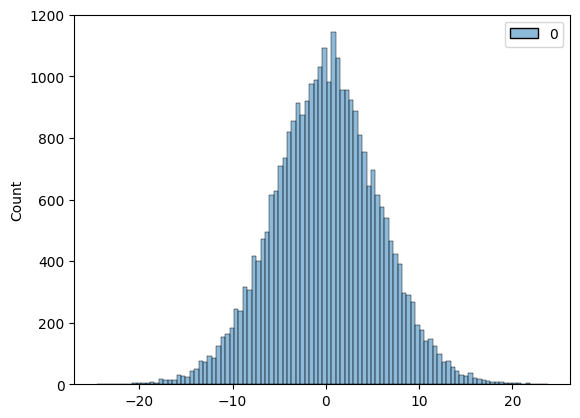

In [48]:
sns.histplot(preds.detach())

In [32]:
losses_per_model

{'model0': tensor(105796.9062, dtype=torch.float64, grad_fn=<AddBackward0>)}

In [ ]:
train_dataset = HMDataset(X_train,y_train)
train_loader = DataLoader(train_dataset, batch_size=100, shuffle=True)

train_tensor_dataset = TensorDataset(torch.tensor(train_df.to_numpy()))
train_tensor_loader = DataLoader(train_tensor_dataset, batch_size=100, shuffle=True)

## Batched Data Loader

In [11]:
train_df.columns = ["user_id", "item_id", "rating"]

In [12]:
bdl = create_batched_dataloaders(train_df, batch_size=5)
val_dataset = TensorDataset(torch.tensor(X_test.to_numpy(), dtype=int), torch.tensor(y_test.to_numpy(), dtype=float))
val_loader = DataLoader(val_dataset, batch_size=1, shuffle=True)

In [13]:
users = {}
for i in tqdm(range(n_users)):
    model = MF(n_users=n_users, n_items=n_items)
    # model = GeneralizedMFOneLayer(n_users=n_users, n_items=n_items)
    users[i] = User(name=i, model=model, optimizer=SGD(model.parameters(), lr=.01))

  0%|          | 0/1760 [00:00<?, ?it/s]

In [14]:
val_loss = new_train(users, bdl, val_loader, epochs=5, graph=graph)

/home/james/git/research/fed-learning/.venv/lib/python3.10/site-packages/torch/nn/modules/loss.py:535: UserWarning: Using a target size (torch.Size([1])) that is different to the input size (torch.Size([1, 1])). This will likely lead to incorrect results due to broadcasting. Please ensure they have the same size.
  return F.mse_loss(input, target, reduction=self.reduction)
  0%|                                                                                                                               | 0/17975 [00:00<?, ?it/s]/home/james/git/research/fed-learning/.venv/lib/python3.10/site-packages/torch/nn/modules/loss.py:535: UserWarning: Using a target size (torch.Size([5])) that is different to the input size (torch.Size([5, 1])). This will likely lead to incorrect results due to broadcasting. Please ensure they have the same size.
  return F.mse_loss(input, target, reduction=self.reduction)
Epoch 1 Loss: 5.94968 :   0%|                                                             

Epoch 1
Train Loss: 5.370469326281586
Validation Loss: 4.890749205038785
Time Elapsed: 54.926706 sec


Epoch 2 Loss: 3.53971 : 100%|██████████████████████████████████████████████████████████████████████████████████████████| 17975/17975 [00:46<00:00, 384.28it/s]


Epoch 2
Train Loss: 3.5366117806516084
Validation Loss: 4.417680419361508
Time Elapsed: 53.296760 sec


Epoch 3 Loss: 2.70200 : 100%|██████████████████████████████████████████████████████████████████████████████████████████| 17975/17975 [00:45<00:00, 391.16it/s]


Epoch 3
Train Loss: 2.6991532826679716
Validation Loss: 4.151373885835797
Time Elapsed: 52.475753 sec


Epoch 4 Loss: 2.21818 : 100%|██████████████████████████████████████████████████████████████████████████████████████████| 17975/17975 [00:51<00:00, 349.06it/s]


Epoch 4
Train Loss: 2.223006194408877
Validation Loss: 3.983828904009045
Time Elapsed: 57.992383 sec


Epoch 5 Loss: 1.92010 : 100%|██████████████████████████████████████████████████████████████████████████████████████████| 17975/17975 [00:49<00:00, 362.40it/s]


Epoch 5
Train Loss: 1.9182730025416805
Validation Loss: 3.868040704079952
Time Elapsed: 56.241341 sec


## Decentralized UMF

In [12]:
train_dl = create_dataloader(train_df, dl_type="oaat")
val_df = create_dataloader(val_df, dl_type="oaat")

In [13]:
users = {}
for i in tqdm(range(n_users)):
    # model = MF(n_users=n_users, n_items=n_items)
    model = UMF(n_items)
    # model = GeneralizedMFOneLayer(n_users=n_users, n_items=n_items)
    users[i] = User(id=i, model=model, optimizer=SGD(model.parameters(), lr=.01, weight_decay=.001))

  0%|          | 0/1760 [00:00<?, ?it/s]

In [14]:
val_losses = decentralized_train_loop(users, train_dl, graph=graph)

  0%|          | 0/86480 [00:00<?, ?it/s]

RuntimeError: output with shape [1] doesn't match the broadcast shape [1, 1]